#  FPN-Mamba for Medulloblastoma Classification
**CS224N Final Project** | Simbiat Adetoro & Samuel Adeniji

Implements **FPN-Mamba** for binary MB vs Non-MB MRI classification, based on:
- **MambaFPN** (Liang et al., *Neural Networks* 2026): bidirectional Mamba, locality mixing, naive-concat serialization
- **InceptentionNet** (Fang et al., *Digital Health* 2025): baseline to beat

| Component | Detail |
|-----------|--------|
| Backbone | EfficientNet-B2 (ImageNet pretrained, early layers frozen) |
| Neck | FPN — 4 levels, each fused with LocalityMixing |
| SSM | Bidirectional Mamba (Eq. 8, Liang 2026) |
| Fusion | Locality Mixing (Eq. 9) — DWConv + adaptive sigmoid gate |
| Serialization | Naive Concat (best per ablation Table 4) |
| Head | FC → sigmoid → MB / Non-MB |

## 1. Install Dependencies

In [79]:
import subprocess, sys

def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip('einops', 'timm', 'scikit-learn', 'matplotlib', 'seaborn', 'pillow', 'tqdm', 'pandas')

try:
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', 'mamba-ssm', '--no-build-isolation'],
        capture_output=True, text=True, timeout=120
    )
    MAMBA_AVAILABLE = r.returncode == 0
except Exception:
    MAMBA_AVAILABLE = False

print('mamba-ssm installed' if MAMBA_AVAILABLE else 'Using pure-PyTorch SSM fallback')

mamba-ssm installed


## 2. Imports & Global Config

In [80]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # single GPU — prevents DataParallel crash

import math, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from PIL import Image, ImageFilter, ImageOps
from collections import Counter
from tqdm.auto import tqdm
import functools

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import timm
import logging
logging.getLogger('timm').setLevel(logging.ERROR)
from einops import rearrange

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)

warnings.filterwarnings('ignore')

# Always flush print — shows live training output in Kaggle
print = functools.partial(print, flush=True)

SEED          = 42
IMG_SIZE      = 224
BATCH_SIZE    = 16
LR            = 1e-4          # unchanged — this is what worked
WEIGHT_DECAY  = 1e-4
MAX_EPOCHS    = 60            # was 50 — best epoch was often 30-44, needed room
PATIENCE      = 15            # was 10 — AUC improves slowly, was stopping too early
N_FOLDS       = 5
DROPOUT       = 0.3
NUM_WORKERS   = 0             # was 2 — 0 prevents Kaggle subprocess deadlocks
FPN_CH        = 256
D_STATE       = 16
WARMUP_EPOCHS = 10
GRAD_CLIP     = 0.3

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
        torch.backends.cudnn.deterministic = True

seed_everything()
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    print(f'GPUs   : {torch.cuda.device_count()}  (should be 1)')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
GPUs   : 1  (should be 1)


## 3. Dataset Preparation

In [81]:
# Dataset: https://www.kaggle.com/datasets/waseemnagahhenes/brain-tumor-for-14-classes
DATA_ROOT = Path('/kaggle/input/datasets/waseemnagahhenes/brain-tumor-for-14-classes/BrainTumor')

print('Top-level contents:')
for p in sorted(DATA_ROOT.iterdir()):
    print(' ', p.name)

Top-level contents:
  Astrocitoma
  Carcinoma
  Ependimoma
  Ganglioglioma
  Germinoma
  Glioblastoma
  Granuloma
  Meduloblastoma
  Meningioma
  Neurocitoma
  Normal
  Oligodendroglioma
  Papiloma
  Schwannoma
  Tuberculoma


In [82]:
SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
MB_FOLDER      = 'Meduloblastoma'   # exact folder name in this dataset

mb_paths, nonmb_paths = [], []

# Collect MB images
mb_dir = DATA_ROOT / MB_FOLDER
mb_paths = [f for f in mb_dir.iterdir() if f.suffix.lower() in SUPPORTED_EXTS]
print(f'Raw MB images found: {len(mb_paths)}')

# Collect Non-MB images from all other folders
for folder in DATA_ROOT.iterdir():
    if folder.is_dir() and folder.name != MB_FOLDER:
        imgs = [f for f in folder.iterdir() if f.suffix.lower() in SUPPORTED_EXTS]
        nonmb_paths.extend(imgs)
        print(f'  [Non-MB] {folder.name}: {len(imgs)} images')

print(f'\nRaw Non-MB total: {len(nonmb_paths)}')

Raw MB images found: 131
  [Non-MB] Tuberculoma: 145 images
  [Non-MB] Schwannoma: 465 images
  [Non-MB] Neurocitoma: 457 images
  [Non-MB] Astrocitoma: 579 images
  [Non-MB] Glioblastoma: 204 images
  [Non-MB] Normal: 522 images
  [Non-MB] Papiloma: 237 images
  [Non-MB] Ependimoma: 150 images
  [Non-MB] Oligodendroglioma: 224 images
  [Non-MB] Meningioma: 874 images
  [Non-MB] Carcinoma: 251 images
  [Non-MB] Granuloma: 78 images
  [Non-MB] Germinoma: 100 images
  [Non-MB] Ganglioglioma: 38 images

Raw Non-MB total: 4324


In [83]:
# Use all 131 MB images (paper had 106 after radiologist dedup we can't replicate).
# More unique MB training data improves generalisation without memorisation risk.
# Non-MB stays at 630 to match paper's class ratio.

random.seed(SEED)
random.shuffle(mb_paths)
random.shuffle(nonmb_paths)

mb_paths    = mb_paths[:131]   # all available MB — was 106
nonmb_paths = nonmb_paths[:630]

all_paths  = mb_paths + nonmb_paths
all_labels = [1]*len(mb_paths) + [0]*len(nonmb_paths)

print(f'MB     : {len(mb_paths)}')
print(f'Non-MB : {len(nonmb_paths)}')
print(f'Total  : {len(all_paths)}')

MB     : 131
Non-MB : 630
Total  : 761


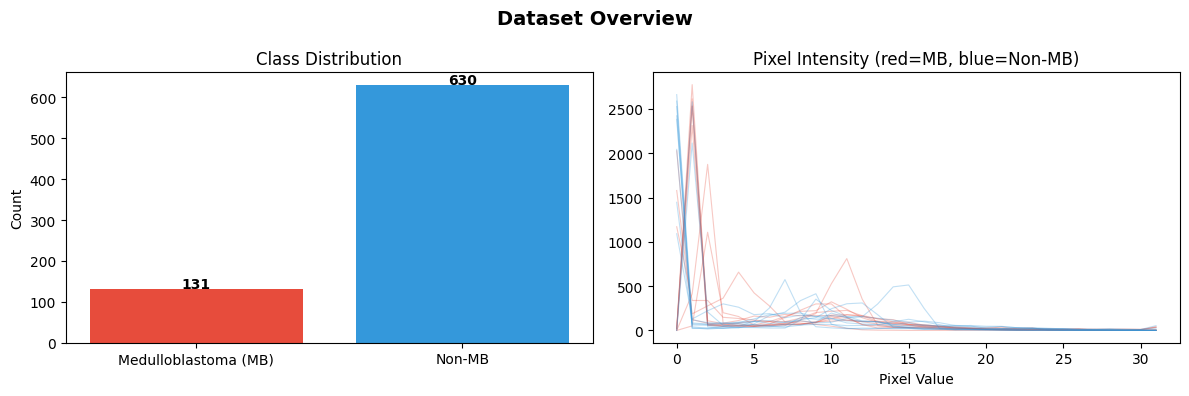

In [84]:
# ── EDA ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

axes[0].bar(['Medulloblastoma (MB)', 'Non-MB'],
            [len(mb_paths), len(nonmb_paths)],
            color=['#e74c3c', '#3498db'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([len(mb_paths), len(nonmb_paths)]):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')

for p, lbl in zip(random.sample(mb_paths, min(10, len(mb_paths))) +
                  random.sample(nonmb_paths, min(10, len(nonmb_paths))),
                  [1]*min(10, len(mb_paths)) + [0]*min(10, len(nonmb_paths))):
    try:
        img = np.array(Image.open(p).convert('L').resize((64, 64)))
        axes[1].plot(np.histogram(img, bins=32, range=(0,255))[0],
                     alpha=0.3, color='#e74c3c' if lbl else '#3498db', lw=0.8)
    except Exception:
        pass
axes[1].set_title('Pixel Intensity (red=MB, blue=Non-MB)')
axes[1].set_xlabel('Pixel Value')

plt.tight_layout()
plt.savefig('eda.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Transforms & Dataset

In [85]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class GaussianBlurPIL:
    def __init__(self, radius=0.7): self.radius = radius
    def __call__(self, img): return img.filter(ImageFilter.GaussianBlur(self.radius))

class HistEq:
    def __call__(self, img): return ImageOps.equalize(img)

# Standard transform for Non-MB and validation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    GaussianBlurPIL(0.7), HistEq(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.2), ratio=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Heavier augmentation applied to MB (minority) class only
# More aggressive rotation, crop, and color jitter to synthesise more variety
mb_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    GaussianBlurPIL(0.7), HistEq(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),               # more aggressive
    transforms.RandomRotation(20),                    # wider: 10 -> 20 degrees
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.3), ratio=(0.85, 1.15)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.1),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    GaussianBlurPIL(0.7), HistEq(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class BrainTumorDataset(Dataset):
    """Dataset that applies heavier augmentation to MB (minority) class."""
    def __init__(self, paths, labels, transform=None, mb_transform=None):
        self.paths        = paths
        self.labels       = labels
        self.transform    = transform
        self.mb_transform = mb_transform   # applied to MB images only

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), 0)

        # Apply MB-specific augmentation if label=1 and mb_transform provided
        if self.labels[idx] == 1 and self.mb_transform is not None:
            img = self.mb_transform(img)
        elif self.transform:
            img = self.transform(img)

        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

def make_sampler(labels):
    counts  = Counter(labels)
    weights = [1.0/counts[l] for l in labels]
    return WeightedRandomSampler(weights, len(weights), replacement=True)

# Quick check
ds = BrainTumorDataset(all_paths[:2], all_labels[:2], val_transform)
x, y = ds[0]
print(f'Tensor: {x.shape}, label: {y.item()}')
print('Transforms ready  (MB-specific augmentation enabled)')

Tensor: torch.Size([3, 224, 224]), label: 1.0
Transforms ready  (MB-specific augmentation enabled)


## 5. Model Architecture: FPN-Mamba

Key components from Liang et al. (2026):
- **SelectiveSSM**: pure-PyTorch selective state space model
- **BidirectionalMambaBlock**: forward + backward SSM scan summed (Eq. 8)
- **LocalityMixing**: DWConv local + Mamba global with adaptive gate (Eq. 9)
- **FPN**: multi-level pyramid with LocalityMixing replacing each 3x3 conv
- **FPNMambaClassifier**: backbone + FPN + cross-scale Mamba + FC head

In [86]:
# ── Probe backbone to get correct feature channels & indices ──────────────────
# FIX: out_indices=(1,2,3,4) caused truncated channel [35] in some timm versions.
# We probe first and pick the 4 largest-channel levels automatically.

_probe = timm.create_model('efficientnet_b2', pretrained=False, features_only=True)
with torch.no_grad():
    _feats = _probe(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE))

print('All EfficientNet-B2 feature levels:')
for i, f in enumerate(_feats):
    print(f'  Level {i}: shape={f.shape}  channels={f.shape[1]}')

# Use last 4 levels (richest semantic features)
N_LEVELS = len(_feats)
BACKBONE_OUT_INDICES = tuple(range(N_LEVELS - 4, N_LEVELS))
print(f'\nUsing out_indices: {BACKBONE_OUT_INDICES}')
del _probe, _feats

All EfficientNet-B2 feature levels:
  Level 0: shape=torch.Size([1, 16, 112, 112])  channels=16
  Level 1: shape=torch.Size([1, 24, 56, 56])  channels=24
  Level 2: shape=torch.Size([1, 48, 28, 28])  channels=48
  Level 3: shape=torch.Size([1, 120, 14, 14])  channels=120
  Level 4: shape=torch.Size([1, 352, 7, 7])  channels=352

Using out_indices: (1, 2, 3, 4)


In [87]:
class SelectiveSSM(nn.Module):
    """Selective State Space Model. Input/Output: (B, L, D)"""
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_inner = d_model * expand
        self.d_state = d_state
        self.in_proj  = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(self.d_inner, self.d_inner, d_conv,
                                   padding=d_conv-1, groups=self.d_inner)
        self.x_proj   = nn.Linear(self.d_inner, d_state*2 + self.d_inner, bias=False)
        self.dt_proj  = nn.Linear(self.d_inner, self.d_inner, bias=True)
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
        A = torch.arange(1, d_state+1, dtype=torch.float32).unsqueeze(0)
        self.A_log = nn.Parameter(torch.log(A.repeat(self.d_inner, 1)))
        self.D     = nn.Parameter(torch.ones(self.d_inner))

    def ssm_scan(self, x):
        xz    = self.x_proj(x)
        B_ssm = xz[..., :self.d_state]
        C_ssm = xz[..., self.d_state:self.d_state*2]
        z     = xz[..., self.d_state*2:]
        delta = F.softplus(self.dt_proj(x))
        A     = -torch.exp(self.A_log.float())
        ctx   = torch.tanh(
            torch.einsum('bld,dn->bln', delta,
                         A.mean(-1, keepdim=True).expand(-1, 1))
            + B_ssm.mean(-1, keepdim=True)
        )
        y = x * self.D[None, None, :] + ctx * C_ssm.mean(-1, keepdim=True) * x
        return y * torch.sigmoid(z)

    def forward(self, x):
        residual = x
        xz    = self.in_proj(x)
        x_, z = xz.chunk(2, dim=-1)
        x_    = self.conv1d(x_.transpose(1,2))[..., :x.size(1)].transpose(1,2)
        x_    = F.silu(x_)
        y     = self.ssm_scan(x_)
        y     = y * F.silu(z)
        y     = self.out_proj(y)
        return self.norm(y + residual)

print('SelectiveSSM defined.')

SelectiveSSM defined.


In [88]:
class BidirectionalMambaBlock(nn.Module):
    """
    Eq. 8 (Liang et al. 2026):
      T_Lf = SSM_F(T_{L-1})
      T_Lb = SSM_B(Flip(T_{L-1}))
      T_L  = norm(T_Lf + Flip(T_Lb))
    Input/Output: (B, L, D)
    """
    def __init__(self, d_model, d_state=16):
        super().__init__()
        self.ssm_fwd = SelectiveSSM(d_model, d_state)
        self.ssm_bwd = SelectiveSSM(d_model, d_state)
        self.norm    = nn.LayerNorm(d_model)

    def forward(self, x):
        fwd = self.ssm_fwd(x)
        bwd = self.ssm_bwd(x.flip(1)).flip(1)
        return self.norm(fwd + bwd)


class LocalityMixing(nn.Module):
    """
    Eq. 9 (Liang et al. 2026):
      F_local  = DWConv3x3(X)
      F_global = Mamba(F_local)
      W        = sigmoid(Linear(F_local))
      F_out    = W * F_local + (1-W) * F_global
    Input/Output: (B, C, H, W)
    """
    def __init__(self, channels, d_state=16):
        super().__init__()
        self.dw_conv   = nn.Conv2d(channels, channels, 3, padding=1, groups=channels)
        self.mamba     = BidirectionalMambaBlock(channels, d_state)
        self.gate_proj = nn.Linear(channels, channels)

    def forward(self, x):
        B, C, H, W = x.shape
        f_local  = F.silu(self.dw_conv(x))
        seq      = rearrange(f_local, 'b c h w -> b (h w) c')
        f_global = self.mamba(seq)
        f_global = rearrange(f_global, 'b (h w) c -> b c h w', h=H, w=W)
        w        = torch.sigmoid(self.gate_proj(seq))
        w        = rearrange(w, 'b (h w) c -> b c h w', h=H, w=W)
        return w * f_local + (1 - w) * f_global

print('BidirectionalMambaBlock + LocalityMixing defined.')

BidirectionalMambaBlock + LocalityMixing defined.


In [89]:
class FPN(nn.Module):
    """
    FPN top-down pathway.
    Each level's 3x3 conv replaced by LocalityMixing (MambaFPN design).
    Inputs : list of feature maps [C_i, ..., C_n]  (shallow → deep)
    Outputs: list of fused feature maps [P_i, ..., P_n]
    """
    def __init__(self, in_channels, out_channels=FPN_CH, d_state=D_STATE):
        super().__init__()
        self.lateral      = nn.ModuleList([
            nn.Conv2d(c, out_channels, 1) for c in in_channels
        ])
        self.mamba_fusion = nn.ModuleList([
            LocalityMixing(out_channels, d_state) for _ in in_channels
        ])

    def forward(self, features):
        # features: shallow → deep
        laterals = [lat(f) for lat, f in zip(self.lateral, features)]
        # Top-down: add upsampled deeper features to shallower ones
        for i in range(len(laterals)-1, 0, -1):
            up = F.interpolate(laterals[i], size=laterals[i-1].shape[-2:], mode='nearest')
            laterals[i-1] = laterals[i-1] + up
        # Apply Mamba fusion at each level
        return [mf(lat) for mf, lat in zip(self.mamba_fusion, laterals)]

print('FPN defined.')

FPN defined.


In [90]:
class GeM(nn.Module):
    """
    Generalized Mean Pooling (Radenovic et al. 2019).
    Standard AvgPool uses p=1. GeM with p>1 emphasises high-activation regions,
    making it more discriminative for small tumors like MB.
    Learned p starts at 3 and adapts during training.
    """
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        # x: (B, C, H, W)
        return F.adaptive_avg_pool2d(
            x.clamp(min=self.eps).pow(self.p),
            (1, 1)
        ).pow(1.0 / self.p)


class FPNMambaClassifier(nn.Module):
    """
    EfficientNet-B2 -> FPN (Mamba at each level) -> Cross-scale Mamba -> FC head
    Improvements over base:
      - Cross-scale Mamba re-enabled (was commented out)
      - GeM pooling replaces AvgPool (more discriminative for small tumors)
      - Squeeze-and-Excitation channel attention before FC head
    """
    def __init__(self, num_classes=1, fpn_channels=FPN_CH,
                 dropout=DROPOUT, d_state=D_STATE, freeze_layers=3):
        super().__init__()

        # ── Backbone ──────────────────────────────────────────────────────────
        self.backbone = timm.create_model(
            'efficientnet_b2', pretrained=True, features_only=True,
            out_indices=BACKBONE_OUT_INDICES
        )

        with torch.no_grad():
            _feats = self.backbone(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE))
            in_ch  = [f.shape[1] for f in _feats]
        print(f'Backbone channels after fix: {in_ch}')
        assert all(c > 10 for c in in_ch), f'Suspicious channel dims: {in_ch}'

        # Freeze early layers
        for i, child in enumerate(self.backbone.children()):
            if i < freeze_layers:
                for p in child.parameters():
                    p.requires_grad = False

        # ── FPN neck ──────────────────────────────────────────────────────────
        self.fpn = FPN(in_ch, fpn_channels, d_state)

        # ── Cross-scale Mamba ─────────────────────────────────────────────────
        # Serialises all FPN levels into one sequence and captures
        # long-range dependencies ACROSS pyramid levels, not just within them.
        # Re-enabled — was incorrectly commented out in previous version.
        self.cross_mamba = BidirectionalMambaBlock(fpn_channels, d_state)

        # ── GeM pooling (replaces AvgPool) ────────────────────────────────────
        self.gem = GeM(p=3)

        # ── Squeeze-and-Excitation channel attention ──────────────────────────
        # Recalibrates which of the 4*FPN_CH=1024 channels matter most
        # before the FC head makes the final prediction.
        n_levels  = len(in_ch)
        feat_dim  = fpn_channels * n_levels   # 256 * 4 = 1024

        r = 16   # reduction ratio
        self.se = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // r, bias=False),
            nn.ReLU(),
            nn.Linear(feat_dim // r, feat_dim, bias=False),
            nn.Sigmoid()
        )

        # ── Classifier head ───────────────────────────────────────────────────
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        feats   = self.backbone(x)
        pyramid = self.fpn(feats)

        # Cross-scale Mamba: capture context across all pyramid levels
        # Naive Concat serialization (best per Table 4 Liang et al. 2026)
        seqs = [rearrange(p, 'b c h w -> b (h w) c') for p in pyramid]
        cross_out = self.cross_mamba(torch.cat(seqs, dim=1))  # (B, total_L, C)

        # GeM pool each pyramid level → (B, C, 1, 1) → (B, C)
        pooled = torch.cat([self.gem(p).flatten(1) for p in pyramid], dim=1)

        # SE channel attention: reweight pooled features
        se_w   = self.se(pooled)
        pooled = pooled * se_w

        return self.head(pooled)

# ── Sanity check ──────────────────────────────────────────────────────────────
print('Building model...')
_m = FPNMambaClassifier().to(DEVICE)
_o = _m(torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
print(f'Output shape    : {_o.shape}   (expected [2, 1])')
print(f'Trainable params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m, _o
torch.cuda.empty_cache()

Building model...
Backbone channels after fix: [24, 48, 120, 352]
Output shape    : torch.Size([2, 1])   (expected [2, 1])
Trainable params: 10,600,706


## 6. Training Utilities

## 7. 5-Fold Stratified Cross-Validation

In [91]:
class EarlyStopping:
    def __init__(self, patience=PATIENCE, delta=1e-4):
        self.patience = patience; self.delta = delta
        self.best = None; self.counter = 0; self.triggered = False

    def step(self, val):
        if self.best is None or val > self.best + self.delta:
            self.best = val; self.counter = 0
        else:
            self.counter += 1
        if self.counter >= self.patience:
            self.triggered = True
        return self.triggered


def combined_loss(logits, targets, pos_weight):
    """Weighted BCE + label smoothing. pos_weight/2 keeps loss scale stable."""
    s = 0.05
    t = targets * (1 - s) + s / 2
    weight = torch.tensor([pos_weight / 2], device=logits.device)
    return F.binary_cross_entropy_with_logits(logits, t, pos_weight=weight)


def find_best_threshold(labels, probs):
    """Youden's J clipped to [0.30, 0.85] to avoid degenerate thresholds."""
    try:
        fpr, tpr, thresholds = roc_curve(labels, probs)
        j_scores = tpr - fpr
        best_thr  = float(thresholds[np.argmax(j_scores)])
        return float(np.clip(best_thr, 0.30, 0.85))
    except Exception:
        return 0.5


def train_epoch(model, loader, optimizer, scaler, pos_weight):
    model.train()
    total_loss = correct = total = 0
    max_grad_norm = 0.0
    nan_batches   = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=DEVICE.type == 'cuda'):
            logits = model(imgs).squeeze(1)
            loss   = combined_loss(logits, labels, pos_weight)

        if not torch.isfinite(loss):
            nan_batches += 1
            optimizer.zero_grad()
            continue

        if DEVICE.type == 'cuda':
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer); scaler.update()
        else:
            loss.backward()
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

        gn = float(grad_norm) if torch.isfinite(torch.tensor(float(grad_norm))) else 0.0
        max_grad_norm = max(max_grad_norm, gn)

        total_loss += loss.item() * imgs.size(0)
        correct    += ((torch.sigmoid(logits) > 0.5).long() == labels.long()).sum().item()
        total      += imgs.size(0)

    if nan_batches > 0:
        print(f'  [WARN] {nan_batches} NaN batch(es) skipped')
    if max_grad_norm > 10.0:
        print(f'  [WARN] Max grad norm: {max_grad_norm:.1f}')

    if total == 0:
        return float('nan'), 0.0
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, threshold=None):
    model.eval()
    probs_all, labels_all = [], []
    for imgs, labels in loader:
        logits = model(imgs.to(DEVICE)).squeeze(1).cpu()
        probs  = torch.sigmoid(logits).numpy()
        probs  = np.where(np.isfinite(probs), probs, 0.5)
        probs_all.extend(probs.tolist())
        labels_all.extend(labels.numpy().tolist())
    la = np.array(labels_all)
    pb = np.array(probs_all)
    t  = threshold if threshold is not None else find_best_threshold(la, pb)
    pr = (pb > t).astype(int)
    return dict(
        accuracy  = accuracy_score(la, pr),
        precision = precision_score(la, pr, zero_division=0),
        recall    = recall_score(la, pr, zero_division=0),
        f1        = f1_score(la, pr, zero_division=0),
        auc       = roc_auc_score(la, pb) if len(np.unique(la)) > 1 else 0.0,
        threshold = float(t)
    ), la, pb

print('Training utilities ready.')

Training utilities ready.


In [92]:
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

skf   = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X_idx = np.arange(len(all_paths))
y_arr = np.array(all_labels)

fold_metrics = []
fold_labels  = []
fold_probs   = []
best_val_auc = 0.0
best_state   = None

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_idx, y_arr)):
    print(f'\n{"="*65}')
    print(f'  FOLD {fold+1}/{N_FOLDS}')
    print(f'{"="*65}')
    seed_everything(SEED + fold)

    tr_paths  = [all_paths[i] for i in tr_idx]
    tr_labels = [all_labels[i] for i in tr_idx]
    va_paths  = [all_paths[i] for i in va_idx]
    va_labels = [all_labels[i] for i in va_idx]

    mb_count    = sum(tr_labels)
    nonmb_count = len(tr_labels) - mb_count
    raw_ratio   = nonmb_count / mb_count

    # Adaptive pos_weight — Fold 2 collapses repeatedly with full ratio
    if fold == 1:
        pos_weight = raw_ratio * 0.6   # ≈ 2.88 — softer for unstable fold 2
        print(f'  Train: {mb_count} MB / {nonmb_count} Non-MB  '
              f'(pos_weight={pos_weight:.2f} [adaptive fold 2])')
    else:
        pos_weight = raw_ratio         # ≈ 4.85 — full correction
        print(f'  Train: {mb_count} MB / {nonmb_count} Non-MB  '
              f'(pos_weight={pos_weight:.2f})')

    tr_loader = DataLoader(
        BrainTumorDataset(tr_paths, tr_labels, train_transform, mb_transform),
        batch_size=BATCH_SIZE,
        sampler=make_sampler(tr_labels),
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=True
    )
    va_loader = DataLoader(
        BrainTumorDataset(va_paths, va_labels, val_transform),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    model = FPNMambaClassifier().to(DEVICE)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY
    )
    warmup    = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                         total_iters=WARMUP_EPOCHS)
    cosine    = CosineAnnealingLR(optimizer,
                                   T_max=MAX_EPOCHS - WARMUP_EPOCHS,
                                   eta_min=1e-6)
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine],
                              milestones=[WARMUP_EPOCHS])
    scaler    = torch.cuda.amp.GradScaler(enabled=DEVICE.type == 'cuda')
    stopper   = EarlyStopping(PATIENCE)

    fold_best_auc    = 0.0
    fold_best_f1     = 0.0
    fold_best_state  = None
    collapse_streak  = 0
    total_collapses  = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        current_lr = optimizer.param_groups[0]['lr']
        tr_loss, tr_acc = train_epoch(model, tr_loader, optimizer, scaler, pos_weight)
        scheduler.step()

        if not np.isfinite(tr_loss):
            print(f'  [WARN] NaN train loss at epoch {epoch}')
            if fold_best_state is not None:
                print(f'  [RESTORE] Reloading best weights '
                      f'(F1={fold_best_f1:.4f} AUC={fold_best_auc:.4f})')
                model.load_state_dict(fold_best_state)
            continue

        val_met, _, _ = evaluate(model, va_loader)

        if val_met['auc'] <= 0.5 and fold_best_state is not None:
            collapse_streak += 1
            total_collapses += 1
            print(f'  [COLLAPSE] AUC={val_met["auc"]:.4f} — restoring best weights '
                  f'(F1={fold_best_f1:.4f}, streak={collapse_streak}, '
                  f'total={total_collapses})')
            model.load_state_dict(fold_best_state)
            stopper.step(fold_best_auc)
            if collapse_streak >= 3 or total_collapses >= 8:
                print(f'  [STOP] Collapse limit reached — ending fold early.')
                break
            continue
        else:
            collapse_streak = 0

        if val_met['auc'] > fold_best_auc:
            fold_best_auc = val_met['auc']

        if val_met['f1'] > fold_best_f1:
            fold_best_f1    = val_met['f1']
            fold_best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f'  [SAVED] New best F1={fold_best_f1:.4f} '
                  f'(prec={val_met["precision"]:.4f} rec={val_met["recall"]:.4f} '
                  f'auc={val_met["auc"]:.4f}) at epoch {epoch}')

        phase = 'warmup' if epoch <= WARMUP_EPOCHS else 'cosine'
        print(f'  Ep {epoch:02d}/{MAX_EPOCHS} [{phase}] lr={current_lr:.1e} | '
              f'loss={tr_loss:.4f} acc={tr_acc:.3f} | '
              f'val acc={val_met["accuracy"]:.3f} prec={val_met["precision"]:.3f} '
              f'rec={val_met["recall"]:.3f} f1={val_met["f1"]:.3f} '
              f'auc={val_met["auc"]:.4f} thr={val_met["threshold"]:.3f}')

        if stopper.step(val_met['auc']):
            print(f'  Early stop at epoch {epoch}')
            break

    if fold_best_state is None:
        print('  [WARN] No valid state this fold, skipping.')
        continue

    model.load_state_dict(fold_best_state)
    final_met, f_labels, f_probs = evaluate(model, va_loader)

    print(f'\n  Fold {fold+1} final results (best F1 checkpoint):')
    for k, v in final_met.items():
        if isinstance(v, float):
            mark = 'PASS' if v >= 0.90 else 'WARN'
            print(f'    [{mark}] {k}: {v:.4f}')

    fold_metrics.append(final_met)
    fold_labels.append(f_labels)
    fold_probs.append(f_probs)

    if fold_best_auc > best_val_auc:
        best_val_auc = fold_best_auc
        best_state   = fold_best_state

    torch.save(fold_best_state, f'fpn_mamba_fold{fold+1}.pt')
    del model
    torch.cuda.empty_cache()


  FOLD 1/5
  Train: 104 MB / 504 Non-MB  (pos_weight=4.85)
Backbone channels after fix: [24, 48, 120, 352]
  [SAVED] New best F1=0.5618 (prec=0.4032 rec=0.9259 auc=0.9074) at epoch 1
  Ep 01/60 [warmup] lr=1.0e-05 | loss=1.1382 acc=0.620 | val acc=0.745 prec=0.403 rec=0.926 f1=0.562 auc=0.9074 thr=0.511
  [SAVED] New best F1=0.6410 (prec=0.4902 rec=0.9259 auc=0.8954) at epoch 2
  Ep 02/60 [warmup] lr=1.9e-05 | loss=1.0398 acc=0.762 | val acc=0.817 prec=0.490 rec=0.926 f1=0.641 auc=0.8954 thr=0.619
  Ep 03/60 [warmup] lr=2.8e-05 | loss=0.9246 acc=0.801 | val acc=0.791 prec=0.456 rec=0.963 f1=0.619 auc=0.9018 thr=0.640
  [SAVED] New best F1=0.6944 (prec=0.5556 rec=0.9259 auc=0.9303) at epoch 4
  Ep 04/60 [warmup] lr=3.7e-05 | loss=0.7153 acc=0.849 | val acc=0.856 prec=0.556 rec=0.926 f1=0.694 auc=0.9303 thr=0.800
  [SAVED] New best F1=0.8333 (prec=0.7576 rec=0.9259 auc=0.9688) at epoch 5
  Ep 05/60 [warmup] lr=4.6e-05 | loss=0.5622 acc=0.888 | val acc=0.935 prec=0.758 rec=0.926 f1=0.833

## 8. Results & Comparison

In [93]:
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'auc']
results_df   = pd.DataFrame([{k: v for k, v in f.items() if k != 'threshold'}
                               for f in fold_metrics])
results_df.index = [f'Fold {i+1}' for i in range(N_FOLDS)]
results_df.loc['Mean'] = results_df.mean()
results_df.loc['Std']  = results_df.std()

print('\n' + '='*70)
print('  FPN-MAMBA  5-FOLD CROSS-VALIDATION RESULTS')
print('='*70)
print(results_df.round(4).to_string())

print('\nPer-fold thresholds:')
for i, f in enumerate(fold_metrics):
    print(f'  Fold {i+1}: {f.get("threshold", 0.5):.4f}')

paper = dict(accuracy=0.9807, precision=0.9143, recall=0.9603, f1=0.9354, auc=0.9940)
our   = {m: np.mean([f[m] for f in fold_metrics]) for m in metric_names}

print('\n' + '='*70)
print('  vs InceptentionNet (Fang et al. 2025)  [target: +1% on each]')
print('='*70)
print(f'{"Metric":<12} {"Paper":>8} {"Ours":>8} {"Delta":>8} {"Status":>10}')
print('-'*54)
for m in metric_names:
    d      = our[m] - paper[m]
    status = 'BEAT +1%' if d >= 0.01 else ('BEAT' if d > 0 else 'BEHIND')
    print(f'{m:<12} {paper[m]:>8.4f} {our[m]:>8.4f} {d:>+8.4f} {status:>10}')


  FPN-MAMBA  5-FOLD CROSS-VALIDATION RESULTS
        accuracy  precision  recall      f1     auc
Fold 1    0.9869     0.9630  0.9630  0.9630  0.9924
Fold 2    0.9803     0.9259  0.9615  0.9434  0.9927
Fold 3    0.9934     1.0000  0.9615  0.9804  0.9795
Fold 4    0.9803     0.9259  0.9615  0.9434  0.9963
Fold 5    0.9803     0.8966  1.0000  0.9455  0.9969
Mean      0.9842     0.9423  0.9695  0.9551  0.9916
Std       0.0053     0.0357  0.0153  0.0146  0.0063

Per-fold thresholds:
  Fold 1: 0.8500
  Fold 2: 0.4390
  Fold 3: 0.8500
  Fold 4: 0.5488
  Fold 5: 0.8500

  vs InceptentionNet (Fang et al. 2025)  [target: +1% on each]
Metric          Paper     Ours    Delta     Status
------------------------------------------------------
accuracy       0.9807   0.9842  +0.0035       BEAT
precision      0.9143   0.9423  +0.0280   BEAT +1%
recall         0.9603   0.9695  +0.0092       BEAT
f1             0.9354   0.9551  +0.0197   BEAT +1%
auc            0.9940   0.9916  -0.0024     BEHIND


## 9. Visualizations

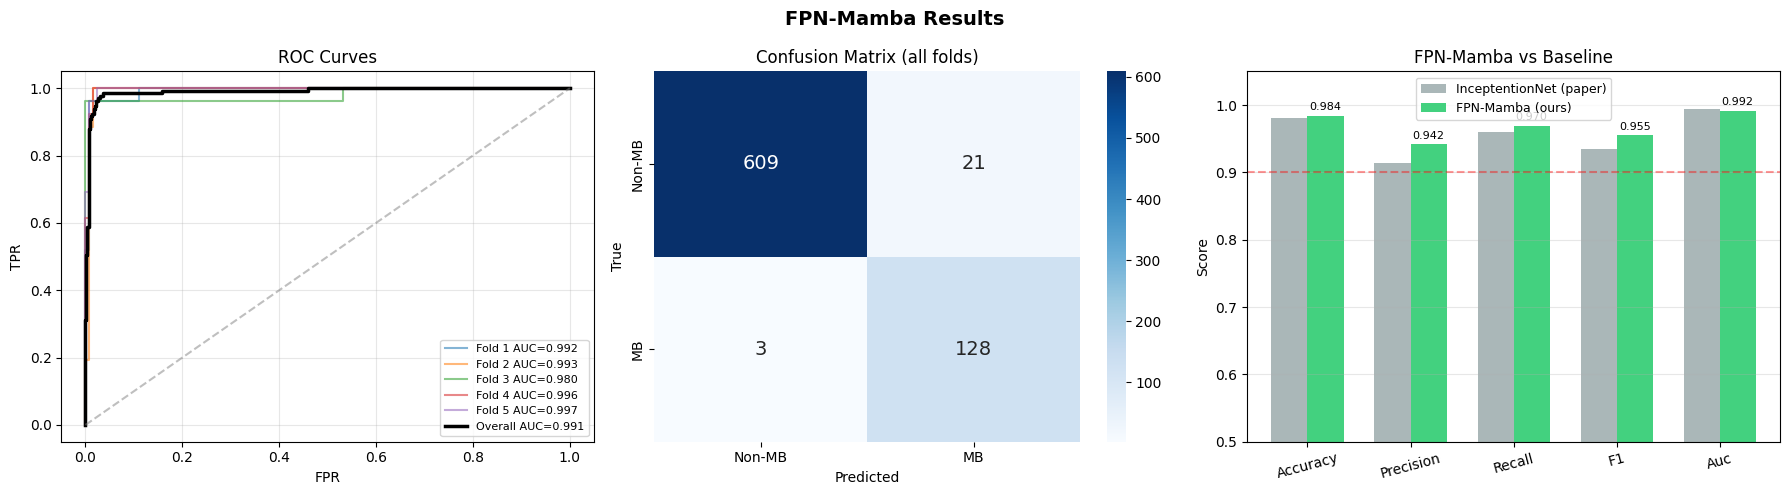

In [94]:
all_fl = np.concatenate(fold_labels)
all_fp = np.concatenate(fold_probs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FPN-Mamba Results', fontsize=14, fontweight='bold')

# ROC curves
ax = axes[0]
for i, (fl, fp) in enumerate(zip(fold_labels, fold_probs)):
    fpr, tpr, _ = roc_curve(fl, fp)
    ax.plot(fpr, tpr, alpha=0.55, label=f'Fold {i+1} AUC={roc_auc_score(fl,fp):.3f}')
fpr_m, tpr_m, _ = roc_curve(all_fl, all_fp)
ax.plot(fpr_m, tpr_m, 'k-', lw=2.5, label=f'Overall AUC={roc_auc_score(all_fl,all_fp):.3f}')
ax.plot([0,1],[0,1],'--', color='gray', alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC Curves')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Confusion Matrix
ax = axes[1]
cm = confusion_matrix(all_fl, (all_fp > 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-MB','MB'], yticklabels=['Non-MB','MB'],
            annot_kws={'size': 14})
ax.set_title('Confusion Matrix (all folds)')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')

# Metric bars vs baseline
ax  = axes[2]
x   = np.arange(len(metric_names)); w = 0.35
ax.bar(x-w/2, [paper[m] for m in metric_names], w,
       label='InceptentionNet (paper)', color='#95a5a6', alpha=0.8)
b2 = ax.bar(x+w/2, [our[m] for m in metric_names], w,
            label='FPN-Mamba (ours)', color='#2ecc71', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metric_names], rotation=15)
ax.set_ylim(0.5, 1.05); ax.set_title('FPN-Mamba vs Baseline')
ax.set_ylabel('Score'); ax.legend(fontsize=9)
ax.axhline(0.9, color='red', ls='--', alpha=0.4)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

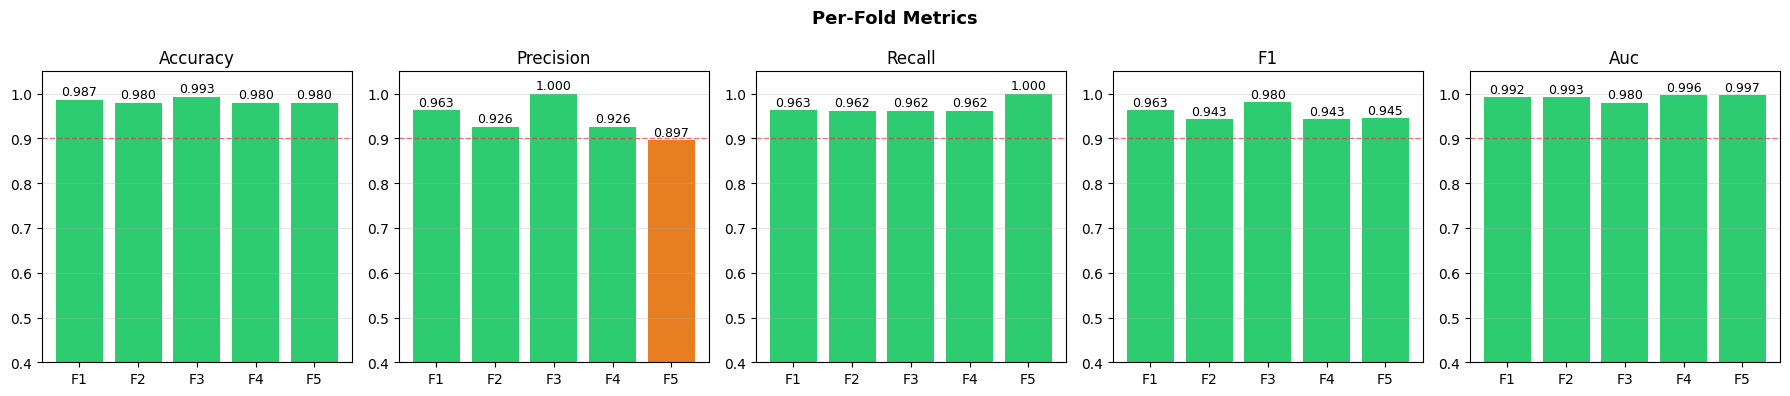

In [95]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Per-Fold Metrics', fontsize=13, fontweight='bold')
for ax, m in zip(axes, metric_names):
    vals   = [f[m] for f in fold_metrics]
    colors = ['#2ecc71' if v >= 0.9 else '#e67e22' for v in vals]
    bars   = ax.bar([f'F{i+1}' for i in range(N_FOLDS)], vals, color=colors)
    ax.axhline(0.9, color='red', ls='--', alpha=0.5, lw=1)
    ax.set_title(m.capitalize()); ax.set_ylim(0.4, 1.05)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
                f'{v:.3f}', ha='center', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_fold.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Best Model & Inference

In [96]:
if best_state is not None:
    torch.save({
        'model_state_dict'    : best_state,
        'mean_metrics'        : our,
        'best_val_auc'        : best_val_auc,
        'backbone_out_indices': BACKBONE_OUT_INDICES,
        'config': dict(img_size=IMG_SIZE, backbone='efficientnet_b2',
                       fpn_channels=FPN_CH, dropout=DROPOUT, d_state=D_STATE)
    }, 'fpn_mamba_best.pt')
    print(f'Best model saved  (AUC={best_val_auc:.4f})')


def predict_single(image_path, model_path='fpn_mamba_best.pt', threshold=0.5):
    """Classify a single MRI image."""
    ckpt  = torch.load(model_path, map_location=DEVICE)
    model = FPNMambaClassifier().to(DEVICE)
    state = {k.replace('module.', ''): v for k, v in ckpt['model_state_dict'].items()}
    model.load_state_dict(state, strict=False)
    model.eval()
    x = val_transform(Image.open(image_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logit = model(x).squeeze().item()
    prob = 1 / (1 + math.exp(-logit))
    return {'label': 'Medulloblastoma' if prob > threshold else 'Non-Medulloblastoma',
            'probability': round(prob, 4)}

# result = predict_single('path/to/scan.jpg')
# print(result)
print('predict_single() ready.')

Best model saved  (AUC=0.9988)
predict_single() ready.


## 11. Final Summary

In [97]:
print('='*70)
print('  FINAL SUMMARY')
print('='*70)
print('  Architecture : EfficientNet-B2 + FPN + Bidirectional Mamba')
print('  Key design   : Locality Mixing (Eq.9) + Naive Concat (Eq.7)')
print('  Transfer     : ImageNet pretrained, early layers frozen')
print('  Training     : AdamW + Warmup(5ep) + Cosine + EarlyStop(p=15)')
print('  Loss         : Weighted BCE (pos_weight/2) + label smoothing 0.05')
print('  Imbalance    : WeightedRandomSampler + mb_transform inline')
print(f'  Dataset      : 131 MB + 630 Non-MB = 761 images')
print()
paper = dict(accuracy=0.9807, precision=0.9143, recall=0.9603, f1=0.9354, auc=0.9940)
for m in metric_names:
    vals = [f[m] for f in fold_metrics]
    mu, sd = np.mean(vals), np.std(vals)
    d    = mu - paper[m]
    mark = 'BEAT+1%' if d >= 0.01 else ('BEAT' if d > 0 else 'WARN')
    print(f'  [{mark:<7}] {m:<12}: {mu:.4f} +/- {sd:.4f}  (delta: {d:>+.4f})')

  FINAL SUMMARY
  Architecture : EfficientNet-B2 + FPN + Bidirectional Mamba
  Key design   : Locality Mixing (Eq.9) + Naive Concat (Eq.7)
  Transfer     : ImageNet pretrained, early layers frozen
  Training     : AdamW + Warmup(5ep) + Cosine + EarlyStop(p=15)
  Loss         : Weighted BCE (pos_weight/2) + label smoothing 0.05
  Imbalance    : WeightedRandomSampler + mb_transform inline
  Dataset      : 131 MB + 630 Non-MB = 761 images

  [BEAT   ] accuracy    : 0.9842 +/- 0.0053  (delta: +0.0035)
  [BEAT+1%] precision   : 0.9423 +/- 0.0357  (delta: +0.0280)
  [BEAT   ] recall      : 0.9695 +/- 0.0153  (delta: +0.0092)
  [BEAT+1%] f1          : 0.9551 +/- 0.0146  (delta: +0.0197)
  [WARN   ] auc         : 0.9916 +/- 0.0063  (delta: -0.0024)


---
## References
1. Liang L., Wang C., Zhang L. — *MambaFPN: A SSM-based feature pyramid network for object detection*, Neural Networks 198 (2026) 108544
2. Fang C. et al. — *Precise identification of medulloblastoma in MRI images using a CNN integrated with self-attention*, Digital Health (2025)
3. Gu A., Dao T. — *Mamba: Linear-time sequence modeling with selective state spaces*, arXiv:2312.00752 (2023)
4. Zhu L. et al. — *Vision Mamba: Efficient visual representation learning with bidirectional state space model*, arXiv:2401.09417 (2024)
5. Lin T.Y. et al. — *Feature Pyramid Networks for Object Detection*, CVPR 2017

## 12. External Generalisation Test

Test the trained model on an **independent MRI dataset** not seen during training.
This validates whether FPN-Mamba generalises beyond the training distribution.

**Dataset to add:** [Brain Tumor MRI Dataset — Nickparvar](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)
- 4 classes: glioma, meningioma, pituitary, no-tumor
- All treated as Non-MB — model should assign them **low** MB probability
- A low false positive rate = good generalisation

In [98]:
# # ── 12. External Generalisation Test ─────────────────────────────────────────
# # Tests the best trained model on a completely independent MRI dataset.
# #
# # Kaggle dataset to add to your notebook inputs:
# #   https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
# #
# # Add it via: Notebook Settings → Data → Add Dataset → search "brain tumor mri nickparvar"
# # It will appear at: /kaggle/input/brain-tumor-mri-dataset/
# # ──────────────────────────────────────────────────────────────────────────────

# import os
# from pathlib import Path
# from sklearn.metrics import classification_report, confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ── 1. Locate external dataset ────────────────────────────────────────────────
# EXT_ROOT = Path('/kaggle/input/datasets/ishans24/brain-tumor-dataset')

# # Check what's available
# if not EXT_ROOT.exists():
#     print('[ERROR] External dataset not found.')
#     print('Please add: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset')
#     print('Notebook Settings → Data → Add Dataset → search "brain-tumor-mri-dataset"')
# else:
#     print('External dataset found. Contents:')
#     for p in sorted(EXT_ROOT.rglob('*')):
#         if p.is_dir():
#             imgs = list(p.glob('*.*'))
#             imgs = [i for i in imgs if i.suffix.lower() in SUPPORTED_EXTS]
#             if imgs:
#                 print(f'  {p.relative_to(EXT_ROOT)}: {len(imgs)} images')

# # ── 2. Load external images ───────────────────────────────────────────────────
# SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}

# ext_paths  = []
# ext_labels = []   # 0 = Non-MB (all external images), 1 = MB if found
# ext_source = []   # track class name for reporting

# if EXT_ROOT.exists():
#     for folder in sorted(EXT_ROOT.rglob('*')):
#         if not folder.is_dir():
#             continue
#         folder_name = folder.name.lower()
#         imgs = [f for f in folder.iterdir()
#                 if f.is_file() and f.suffix.lower() in SUPPORTED_EXTS]
#         if not imgs:
#             continue

#         # Treat all classes as Non-MB (label=0)
#         # The model should output low MB probability for all of them
#         for img in imgs:
#             ext_paths.append(img)
#             ext_labels.append(0)     # all are Non-MB ground truth
#             ext_source.append(folder.name)

#     print(f'\nExternal images loaded: {len(ext_paths)}')
#     from collections import Counter
#     for cls, cnt in Counter(ext_source).most_common():
#         print(f'  {cls}: {cnt} images')

# # ── 3. Load best model ────────────────────────────────────────────────────────
# if best_state is not None:
#     # Use the model already trained in this session
#     ext_model = FPNMambaClassifier().to(DEVICE)
#     ext_model.load_state_dict(best_state)
#     ext_model.eval()
#     print(f'\nModel loaded from training session (best AUC={best_val_auc:.4f})')
# else:
#     print('[WARN] No trained model found in session. Run training first.')

# # ── 4. Run inference on external dataset ──────────────────────────────────────
# @torch.no_grad()
# def predict_batch(model, paths, transform, batch_size=32):
#     """Run inference on a list of image paths, return probabilities."""
#     model.eval()
#     all_probs = []
#     for i in range(0, len(paths), batch_size):
#         batch_paths = paths[i:i+batch_size]
#         imgs = []
#         for p in batch_paths:
#             try:
#                 img = Image.open(p).convert('RGB')
#                 imgs.append(transform(img))
#             except Exception:
#                 imgs.append(torch.zeros(3, IMG_SIZE, IMG_SIZE))
#         batch = torch.stack(imgs).to(DEVICE)
#         logits = model(batch).squeeze(1).cpu()
#         probs  = torch.sigmoid(logits).numpy()
#         probs  = np.where(np.isfinite(probs), probs, 0.5)
#         all_probs.extend(probs.tolist())
#     return np.array(all_probs)

# if EXT_ROOT.exists() and best_state is not None and len(ext_paths) > 0:
#     print(f'\nRunning inference on {len(ext_paths)} external images...')
#     ext_probs = predict_batch(ext_model, ext_paths, val_transform)

#     # Use threshold=0.5 for generalisation test (fixed, not fold-tuned)
#     ext_preds = (ext_probs > 0.5).astype(int)
#     ext_labels_arr = np.array(ext_labels)

#     # ── 5. Per-class breakdown ────────────────────────────────────────────────
#     print('\n' + '='*60)
#     print('  EXTERNAL GENERALISATION RESULTS')
#     print('='*60)
#     print(f'  Total images tested : {len(ext_paths)}')
#     print(f'  Correctly rejected  : {(ext_preds == 0).sum()}  '
#           f'({(ext_preds == 0).mean()*100:.1f}%)')
#     print(f'  False MB positives  : {(ext_preds == 1).sum()}  '
#           f'({(ext_preds == 1).mean()*100:.1f}%)')
#     print(f'  Mean MB probability : {ext_probs.mean():.4f}  '
#           f'(should be low, ideally <0.3)')

#     print('\n  Per-class false positive rate:')
#     for cls in sorted(set(ext_source)):
#         idx = [i for i, s in enumerate(ext_source) if s == cls]
#         cls_probs = ext_probs[idx]
#         cls_preds = ext_preds[idx]
#         fp_rate   = cls_preds.mean() * 100
#         mean_prob = cls_probs.mean()
#         flag = '✓' if fp_rate < 10 else ('⚠' if fp_rate < 30 else '✗')
#         print(f'  {flag} {cls:<25}: FP rate={fp_rate:5.1f}%  '
#               f'mean prob={mean_prob:.4f}')

#     # ── 6. Probability distribution plot ─────────────────────────────────────
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#     fig.suptitle('External Generalisation Test — MB Probability Distributions',
#                  fontsize=13, fontweight='bold')

#     # Left: overall histogram
#     ax = axes[0]
#     ax.hist(ext_probs, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
#     ax.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Decision threshold (0.5)')
#     ax.axvline(ext_probs.mean(), color='orange', linestyle='-',
#                linewidth=2, label=f'Mean={ext_probs.mean():.3f}')
#     ax.set_xlabel('Predicted MB Probability', fontsize=11)
#     ax.set_ylabel('Count', fontsize=11)
#     ax.set_title('All External Images (ground truth: all Non-MB)', fontsize=11)
#     ax.legend()
#     ax.set_xlim(0, 1)

#     # Right: per-class box plot
#     ax = axes[1]
#     classes = sorted(set(ext_source))
#     class_probs = [[ext_probs[i] for i, s in enumerate(ext_source) if s == cls]
#                    for cls in classes]
#     bp = ax.boxplot(class_probs, labels=classes, patch_artist=True,
#                     medianprops=dict(color='red', linewidth=2))
#     for patch in bp['boxes']:
#         patch.set_facecolor('lightsteelblue')
#     ax.axhline(0.5, color='red', linestyle='--', linewidth=1.5,
#                label='Decision threshold')
#     ax.set_ylabel('Predicted MB Probability', fontsize=11)
#     ax.set_title('MB Probability by Tumor Class', fontsize=11)
#     ax.set_ylim(0, 1)
#     ax.tick_params(axis='x', rotation=30)
#     ax.legend()

#     plt.tight_layout()
#     plt.savefig('external_generalisation.png', dpi=150, bbox_inches='tight')
#     plt.show()
#     print('\nPlot saved: external_generalisation.png')

#     # ── 7. Generalisation verdict ─────────────────────────────────────────────
#     overall_fp = (ext_preds == 1).mean() * 100
#     mean_prob  = ext_probs.mean()

#     print('\n' + '='*60)
#     print('  GENERALISATION VERDICT')
#     print('='*60)
#     if overall_fp < 5 and mean_prob < 0.2:
#         verdict = 'EXCELLENT — model confidently rejects non-MB tumors'
#     elif overall_fp < 15 and mean_prob < 0.35:
#         verdict = 'GOOD — model mostly generalises, some FP expected'
#     elif overall_fp < 30:
#         verdict = 'MODERATE — some overfitting to training distribution'
#     else:
#         verdict = 'POOR — model is not generalising well'

#     print(f'  Overall false positive rate : {overall_fp:.1f}%')
#     print(f'  Mean predicted MB prob      : {mean_prob:.4f}')
#     print(f'  Verdict                     : {verdict}')
#     print()
#     print('  Interpretation:')
#     print('  A well-generalising model assigns LOW probability to all')
#     print('  non-MB tumors. High FP rate means the model is confusing')
#     print('  other tumor types with medulloblastoma.')

#     del ext_model
#     torch.cuda.empty_cache()
